# 转化页优化 A/B 测试分析

## 项目背景

本项目通过 A/B 测试判断新版页面是否能够显著提高用户转化率，并据此提出页面上线建议。

公开数据集：https://www.kaggle.com/datasets/putdejudomthai/ecommerce-ab-testing-2022-dataset1

## 分析目标

1. 检查实验数据质量与分流是否正常；
2. 比较新版页面与旧版页面的用户转化率；
3. 判断新版页面是否带来统计显著的正向提升；
4. 探索不同国家用户是否存在效果差异；
5. 根据实验结果提出业务建议。

# 1. 实验设计

## 1.1 实验分组

- **对照组（control）**：访问旧版页面 `old_page`；
- **实验组（treatment）**：访问新版页面 `new_page`；
- **分流机制**：用户，以 `user_id` 作为唯一标识；
- **预期分流比例**：对照组与实验组为 1:1。

## 1.2 核心指标

核心指标为用户转化率：

$$
\text{转化率}
=
\frac{\text{转化用户数}}{\text{实验用户数}}
$$

其中，`converted=1` 表示用户完成转化，`converted=0` 表示未转化。

## 1.3 研究假设

设新版页面与旧版页面的真实转化率分别为 $p_{\mathrm{new}}$ 和 $p_{\mathrm{old}}$。

- 零假设：$H_0: p_{\mathrm{new}} \leq p_{\mathrm{old}}$
- 备择假设：$H_1: p_{\mathrm{new}} > p_{\mathrm{old}}$

本项目使用**单侧检验**，判断“新版页面能否提高转化率”

# 2. 数据预处理

检查数据规模、字段类型、缺失值、重复用户，以及实验分组与实际访问页面是否一致。

In [1]:
from pathlib import Path
from math import ceil

import numpy as np
import pandas as pd
from scipy.stats import binomtest
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import chisquare, chi2_contingency
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest,
    proportion_confint,
    confint_proportions_2indep,
)
from statsmodels.stats.multitest import multipletests

# 数据加载
ab_df = pd.read_csv('data/ab_data.csv')
countries_df = pd.read_csv('data/countries.csv')

In [2]:
# 检查基本信息
ab_info = ab_df.head().to_string()
countries_info = countries_df.head().to_string()
ab_shape = ab_df.shape

print("ab_data shape:", ab_shape)
print("ab_data head:\n", ab_info)
print("\ncountries shape:", countries_df.shape)
print("countries head:\n", countries_info)

ab_data shape: (294480, 5)
ab_data head:
    user_id timestamp      group landing_page  converted
0   851104   11:48.6    control     old_page          0
1   804228   01:45.2    control     old_page          0
2   661590   55:06.2  treatment     new_page          0
3   853541   28:03.1  treatment     new_page          0
4   864975   52:26.2    control     old_page          1

countries shape: (290586, 2)
countries head:
    user_id country
0   834778      UK
1   928468      US
2   822059      UK
3   711597      UK
4   710616      UK


In [3]:
# 分组和页面匹配情况
is_treatment = ab_df["group"].eq("treatment")
is_new_page = ab_df["landing_page"].eq("new_page")
match_mask = is_treatment.eq(is_new_page)
mismatch_count = (~match_mask).sum()

print(f"分组与实际页面不匹配的记录数：{mismatch_count}")

分组与实际页面不匹配的记录数：3893


In [ ]:
"""
实验要求：
- 对照组用户访问旧版页面；
- 实验组用户访问新版页面。

清洗规则：
1. 删除分组与页面不匹配的记录。
2. 为避免同一用户被重复计入统计分析，每名用户只保留一条记录。
"""

df_clean = ab_df.loc[match_mask].copy()
duplicates = df_clean['user_id'].duplicated().sum()
print(f"重复行: {duplicates}")
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')

重复行: 2


# 3. 最小样本量估计

- 规划基准转化率：12%
- 最小可检测效应（MDE）：相对提升5%
- 对应目标转化率：12% × 1.05 = 12.6%
- 显著性水平：5%
- 统计功效：80%
- 分流比例：1:1
- 单侧检验

MDE 表示在给定显著性水平和统计功效下，实验希望能够识别出的最小业务提升。

In [6]:
baseline_rate = 0.12
relative_mde = 0.05
alpha=0.05
power=0.8
target_rate = baseline_rate * (1 + relative_mde)
absolute_mde = target_rate - baseline_rate

# 两比例效应量 Cohen's h
effect_size = proportion_effectsize(target_rate, baseline_rate)

# 1:1 分流、单侧检验下每组所需样本量
sample_per_group = ceil(
    NormalIndPower().solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative="larger",
    )
)

actual_group_size = (
    df_clean["group"]
    .value_counts()
    .reindex(["control", "treatment"])
)

sample_size_result = pd.DataFrame({
    "项目": [
        "历史基准转化率",
        "目标转化率",
        "相对 MDE",
        "绝对 MDE",
        "每组最小样本量",
        "实际对照组样本量",
        "实际实验组样本量",
    ],
    "结果": [
        f"{baseline_rate:.2%}",
        f"{target_rate:.2%}",
        f"{relative_mde:.2%}",
        f"{absolute_mde:.2%}",
        f"{sample_per_group:,}",
        f"{actual_group_size['control']:,}",
        f"{actual_group_size['treatment']:,}",
    ],
})

display(sample_size_result)

sample_sufficient = bool(
    (actual_group_size >= sample_per_group).all()
)

print(
    "两组样本量均达到预设要求。"
    if sample_sufficient
    else "至少一组样本量未达到预设要求，检验功效可能不足。"
)


,项目,结果
0,历史基准转化率,12.00%
1,目标转化率,12.60%
2,相对 MDE,5.00%
3,绝对 MDE,0.60%
4,每组最小样本量,"37,046"
5,实际对照组样本量,"145,274"
6,实际实验组样本量,"145,311"


两组样本量均达到预设要求。


# 4. SRM（样本比例偏差检验）

用于检查实际分流比例是否显著偏离预设比例。

**实验预期：**

control : treatment = `50%` : `50%`

**假设：**

$H_0$：两组实际比例符合 `50%` : `50%`

$H_1$：两组比例显著偏离 `50%` : `50%`

In [7]:
group_counts = (df_clean["group"].value_counts().reindex(["control", "treatment"], fill_value=0))

n_control = group_counts["control"]
n_treatment = group_counts["treatment"]
n_total = n_control + n_treatment

# 采用 1:1 分流
expected_control_ratio = 0.5
expected_treatment_ratio = 0.5

# 计算两组的实际占比
actual_control_ratio = n_control / n_total
actual_treatment_ratio = n_treatment / n_total

srm_summary = pd.DataFrame({
    "组别": ["control", "treatment"],
    "实际人数": [n_control, n_treatment],
    "实际占比": [
        actual_control_ratio,
        actual_treatment_ratio
    ],
    "期望人数": [
        n_total * expected_control_ratio,
        n_total * expected_treatment_ratio
    ],
    "期望占比": [
        expected_control_ratio,
        expected_treatment_ratio
    ]
})

display(
    srm_summary.style.format({
        "实际占比": "{:.2%}",
        "期望人数": "{:.1f}",
        "期望占比": "{:.2%}"
    })
)

# 卡方检验 
# 原假设 H0：两组实际分流比例与预期 1:1 无显著差异
observed_counts = [n_control, n_treatment]
expected_counts = [
    n_total * expected_control_ratio,
    n_total * expected_treatment_ratio
]

srm_chi2, srm_p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

alpha = 0.05
print(f"SRM 卡方统计量：{srm_chi2:.6f}")
print(f"SRM 检验 P-value：{srm_p_value:.6f}")

if srm_p_value < alpha:
    print("SRM检验不通过：分流比例存在显著偏差。")
else:
    print("SRM检验通过：分流比例无显著偏差")


,组别,实际人数,实际占比,期望人数,期望占比
0,control,145274,49.99%,145292.5,50.00%
1,treatment,145311,50.01%,145292.5,50.00%


SRM 卡方统计量：0.004711
SRM 检验 P-value：0.945278
SRM检验通过：分流比例无显著偏差


# 5. 转化率与置信区间

In [8]:
group_summary = (
    df_clean.groupby("group")["converted"]
    .agg(
        样本量="count",
        转化数="sum",
        转化率="mean",
    )
    .reindex(["control", "treatment"])
)

CI_values = []
for group_name, row in group_summary.iterrows():
    ci_low, ci_high = proportion_confint(
        count=int(row["转化数"]),
        nobs=int(row["样本量"]),
        alpha=alpha,
        method="wilson",
    )
    CI_values.append((ci_low, ci_high))

group_summary["置信区间下限"] = [x[0] for x in CI_values]
group_summary["置信区间上限"] = [x[1] for x in CI_values]

display(group_summary)

,样本量,转化数,转化率,置信区间下限,置信区间上限
group,,,,,
control,145274,17489,0.120386,0.118723,0.122070
treatment,145311,17264,0.118807,0.117154,0.120481


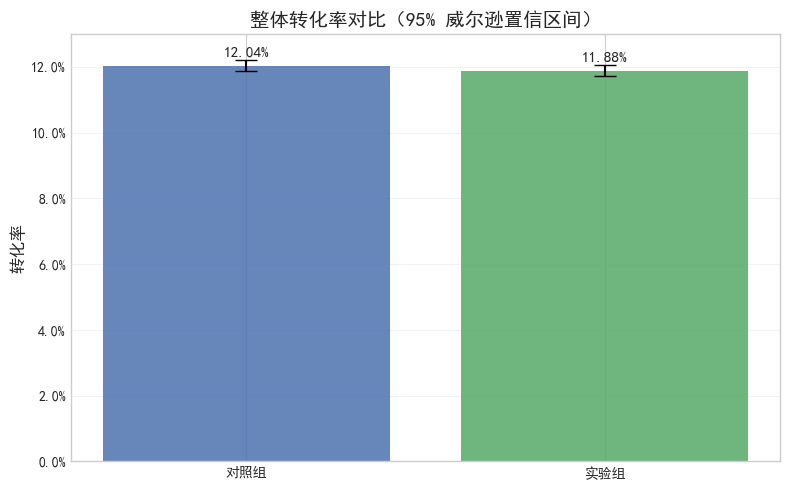

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 图 1：整体转化率对比（威尔逊置信区间）
fig1, ax1 = plt.subplots(figsize=(8, 5))

plot_df = group_summary.copy()
x = np.arange(len(plot_df))
rates = plot_df["转化率"].to_numpy()
lower_error = rates - plot_df["置信区间下限"].to_numpy()
upper_error = plot_df["置信区间上限"].to_numpy() - rates

ax1.bar(
    x, rates,
    yerr=np.vstack([lower_error, upper_error]),
    capsize=8, alpha=0.85, color=['#4C72B0', '#55A868']
)
ax1.set_xticks(x)
ax1.set_xticklabels(["对照组", "实验组"])
ax1.set_ylabel('转化率', fontsize=12)
ax1.set_title('整体转化率对比（95% 威尔逊置信区间）', fontsize=14)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax1.set_ylim(0, 0.13)
ax1.grid(axis="y", alpha=0.25)

for i, rate in enumerate(rates):
    ax1.text(i, rate + upper_error[i] + 0.001, f"{rate:.2%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

# 6. 显著性检验

用于判断两组样本转化率的差异是否可能仅由随机抽样波动造成。

使用两独立样本比例 Z 检验新版页面的转化率是否显著高于旧版页面。

In [10]:
# ---------------- 假设检验（Z检验）----------------
# 单侧检验
count = [
    group_summary.loc["treatment", "转化数"],
    group_summary.loc["control", "转化数"]
]

nobs = [
    group_summary.loc["treatment", "样本量"],
    group_summary.loc["control", "样本量"]
]

# 单侧检验
z_stat, p_value = proportions_ztest(count=count,nobs=nobs,alternative="larger")

print(f"Z统计量: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"结论：P-value < {alpha}，拒绝原假设，新版页面的转化率显著高于旧版页面。")
else:
    print(f"结论：P-value >= {alpha}，暂时不能拒绝原假设，未发现新版页面能够显著提升转化率。")

Z统计量: -1.3116
P-value: 0.9052
结论：P-value >= 0.05，暂时不能拒绝原假设，未发现新版页面能够显著提升转化率。


# 7. 国家维度探索性分析

总体检验反映新版页面对全部实验用户的平均效果，新版本页面没有实现转化提升目标。

下面进一步按照国家，对比实验组和对照组的样本量、转化率及绝对提升。

## 7.1 卡方检验

检查对照组和实验组的国家构成是否均衡。

In [21]:
# 合并国家信息
countries_df = pd.read_csv('data/countries.csv')
countries = countries_df.drop_duplicates(
    subset="user_id", keep="first"
).copy()

df_country = df_clean.merge(countries,on="user_id",how="left",validate="one_to_one")

country_group_table = pd.crosstab(
    df_country["country"],
    df_country["group"],
)
display(country_group_table)

group,control,treatment
country,,
CA,7198,7301
UK,36360,36106
US,101716,101904


**检验假设：**

$H_0$：国家分布与实验分组相互独立，两组的国家构成基本一致。

$H_1$：国家分布与实验分组不独立，两组的国家构成存在显著差异。

In [23]:
country_chi2, country_p, _, _ = chi2_contingency(country_group_table)
print(f"卡方 p-value：{country_p:.6f}")

if country_p < alpha:
    print("提示：不同国家构成存在显著差异。")
else:
    print("结论：未发现国家构成存在显著差异。")


卡方 p-value：0.408431
结论：未发现国家构成存在显著差异。


## 7.2 维度下钻

In [18]:
country_summary = (
    df_country
    .dropna(subset=["country"])
    .groupby(["country", "group"])["converted"]
    .agg(
        样本量="count",
        转化数="sum",
        转化率="mean"
    )
    .reset_index()
)

country_result = country_summary.pivot(index="country",columns="group",values=["样本量", "转化数", "转化率"])
country_result.columns = [f"{group}_{metric}" for metric, group in country_result.columns]
country_result = country_result.reset_index()
country_result["绝对提升"] = (country_result["treatment_转化率"] - country_result["control_转化率"])

display(
    country_result.style.format({
        "control_样本量": "{:,.0f}",
        "treatment_样本量": "{:,.0f}",
        "control_转化数": "{:,.0f}",
        "treatment_转化数": "{:,.0f}",
        "control_转化率": "{:.4%}",
        "treatment_转化率": "{:.4%}",
        "绝对提升": "{:.4%}"
    })
)

,country,control_样本量,treatment_样本量,control_转化数,treatment_转化数,control_转化率,treatment_转化率,绝对提升
0,CA,"7,198","7,301",855,817,11.8783%,11.1902%,-0.6881%
1,UK,"36,360","36,106","4,364","4,375",12.0022%,12.1171%,0.1149%
2,US,"101,716","101,904","12,270","12,072",12.0630%,11.8464%,-0.2166%


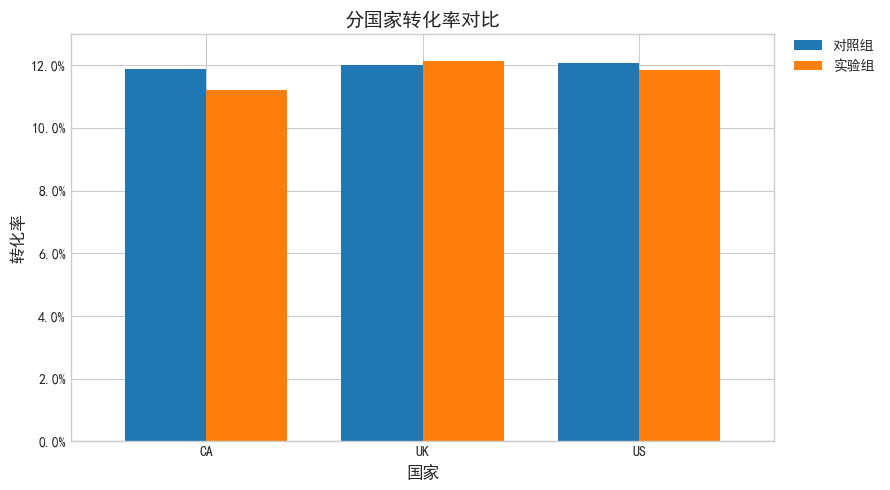

In [20]:
# 图 2：分国家转化率对比
fig2, ax2 = plt.subplots(figsize=(9, 5))
country_plot = (country_result[["country", "control_rate", "treatment_rate"]].set_index("country"))
country_plot.plot(kind="bar",width=0.75,ax=ax2)
ax2.set_ylabel('转化率', fontsize=12)
ax2.set_xlabel('国家', fontsize=12)
ax2.set_title('分国家转化率对比', fontsize=14)
ax2.legend(["对照组", "实验组"],loc="upper left",bbox_to_anchor=(1.02, 1),borderaxespad=0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax2.set_ylim(0, 0.13)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 7.3 交互效应检验

In [25]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

model_df = (df_country.dropna(subset=["country", "group", "converted"]).copy())
model_df["group"] = pd.Categorical(model_df["group"],categories=["control", "treatment"])
model_df["country"] = pd.Categorical(model_df["country"],categories=["CA", "UK", "US"])

# ==================== 无交互模型 ====================
model_no_interaction = smf.logit(
    formula="""
        converted
        ~ C(group, Treatment(reference="control"))
        + C(country, Treatment(reference="CA"))
    """,
    data=model_df
).fit(disp=False)

# ==================== 有交互模型 ====================
model_with_interaction = smf.logit(
    formula="""
        converted
        ~ C(group, Treatment(reference="control"))
        * C(country, Treatment(reference="CA"))
    """,
    data=model_df
).fit(disp=False)


# ==================== 交互效应整体检验 ====================
lr_stat = 2 * (model_with_interaction.llf - model_no_interaction.llf)
df_diff = int(model_with_interaction.df_model - model_no_interaction.df_model)
interaction_p = chi2.sf(lr_stat, df_diff)

print(f"似然比统计量：{lr_stat:.4f}")
print(f"自由度差：{df_diff}")
print(f"p 值：{interaction_p:.6f}")

if interaction_p < alpha:
    print(
        "结论：交互效应显著，"
        "说明新版页面的效果可能因国家不同而不同。"
    )
else:
    print(
        "结论：交互效应不显著，"
        "当前没有充分证据表明新版页面效果因国家不同而不同。"
    )

似然比统计量：2.4657
自由度差：2
p 值：0.291454
结论：交互效应不显著，当前没有充分证据表明新版页面效果因国家不同而不同。


# 8. 总结

本项目基于电商目标转化页优化 A/B 测试数据，对新版页面的用户转化提升效果开展量化评估。

本次实验分组比例均衡，不同组别用户的国家分布构成无显著偏差，样本量满足统计检验的功效要求，实验结果具备可靠的统计参考价值。

从实验结果来看，新版页面转化率为 11.88%，低于旧版页面的 12.04%；单侧比例 Z 检验的 P-value 为 0.9052，未达到 0.05 的统计显著性水平，据此判定当前数据无法支撑 “新版页面可显著提升用户转化率” 的实验假设。进一步从国家维度分析结果看也未发现新版页面在不同国家用户中存在显著差异化效果，无正向细分场景。

新版页面用户转化率为 11.88%，较旧版页面的 12.04% 略有下降；单侧比例 Z 检验结果显示 P 值为 0.9052，未达到 0.05 的统计显著性水平。据此判定，现有数据无法支撑 “新版页面可显著提升用户转化率” 的实验假设。

综上，本次新版页面优化未达成转化率提升的预期目标，不建议直接全量上线。后续建议结合页面点击率、用户停留时长、跳出率、访问路径等过程行为指标，进一步定位新版页面表现不佳的原因，并在完成针对性优化迭代后，再开展新一轮实验验证。

